# Задачи 2.7, 2.9, 2.12

- **2.7.** Отрезок $AB$ длины $2a$ скользит концами по осям. Из начала координат на $AB$ опущен перпендикуляр $OM$. Найти фигуру точек $M$ — четырехлепестковую розу.
- **2.9.** Отрезок длины $b$ скользит концами по осям. Точка $M$ делит $AB$ в отношении $\lambda$. Найти неявное уравнение траектории.
- **2.12.** Найти кривую Вивиани как пересечение сферы радиуса $R$ и цилиндра диаметра $R$, одна образующая которого проходит через центр сферы.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from math import sin, cos, tan, sqrt, pi
from matplotlib.lines import Line2D

EPS = 1e-9
plt.rcParams['figure.figsize'] = (8, 6)
plt.rcParams['axes.grid'] = True

## Общие функции для 2D

In [2]:
def setup_2d(xlim=(-5, 5), ylim=(-5, 5), title=None, xlabel='x', ylabel='y'):
    """Создает 2D-плоскость с осями координат и равным масштабом."""
    fig, ax = plt.subplots()
    ax.axhline(0, linewidth=1)
    ax.axvline(0, linewidth=1)
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    if title:
        ax.set_title(title)
    return fig, ax


def plot_points_2d(ax, points, labels=None):
    """Рисует точки на 2D-графике."""
    labels = labels or [None] * len(points)
    for p, label in zip(points, labels):
        p = np.asarray(p, dtype=float)
        ax.scatter(p[0], p[1], s=45)
        if label:
            ax.text(p[0], p[1], '  ' + label)


def plot_parametric_2d(ax, xy_func, t_range, n=800, label=None):
    """Рисует плоскую параметрическую кривую t -> (x(t), y(t))."""
    t = np.linspace(t_range[0], t_range[1], n)
    xy = np.asarray(xy_func(t), dtype=float)
    ax.plot(xy[0], xy[1], label=label)
    if label:
        ax.legend()
    return xy


def plot_implicit_2d(ax, F, xlim, ylim, n=400, level=0, label=None):
    xs = np.linspace(*xlim, n)
    ys = np.linspace(*ylim, n)
    X, Y = np.meshgrid(xs, ys)
    Z = F(X, Y)

    cs = ax.contour(X, Y, Z, levels=[level])

    if label:
        # Для новых версий matplotlib безопаснее добавлять "фиктивный" элемент легенды
        proxy = Line2D([], [], label=label)
        handles, labels = ax.get_legend_handles_labels()
        handles.append(proxy)
        labels.append(label)
        ax.legend(handles, labels)

    return cs

## Задача 2.7 — четырехлепестковая роза

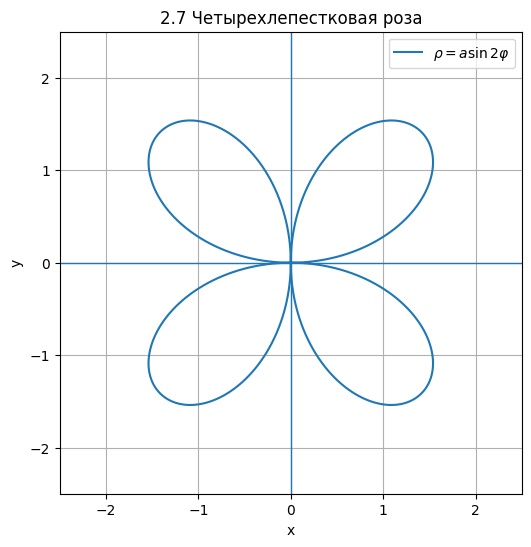

In [3]:
a = 2.0

# КАК ЭТО ДОЛЖНО БЫТЬ
def rose_xy(phi, a=a):
    rho = a * np.sin(2 * phi)
    return np.vstack([rho * np.cos(phi), rho * np.sin(phi)])

fig, ax = setup_2d((-2.5, 2.5), (-2.5, 2.5), title='2.7 Четырехлепестковая роза')
plot_parametric_2d(ax, rose_xy, (0, 2*np.pi), n=1200, label=r'$\rho=a\sin 2\varphi$')
plt.show()

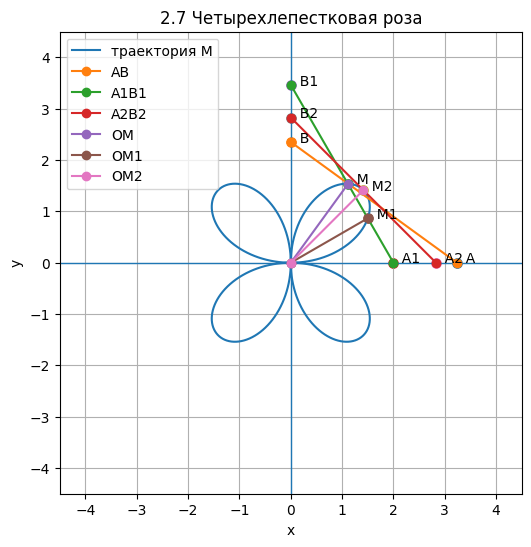

In [4]:
# A=(2a cos t,0), B=(0,2a sin t); foot O->AB = M.
def segment_endpoints(t, a=a):
    return np.array([2*a*np.cos(t), 0.0]), np.array([0.0, 2*a*np.sin(t)])


def foot_from_origin_to_line(A, B):
    A = np.asarray(A, dtype=float)
    B = np.asarray(B, dtype=float)
    AB = B - A
    # проекция точки O на прямую A + s AB
    s = -np.dot(A, AB) / np.dot(AB, AB)
    return A + s * AB

t0 = np.pi / 5
A, B = segment_endpoints(t0)
M = foot_from_origin_to_line(A, B)

t1 = np.pi / 3
A1, B1 = segment_endpoints(t1)
M1 = foot_from_origin_to_line(A1, B1)

t2 = np.pi / 4
A2, B2 = segment_endpoints(t2)
M2 = foot_from_origin_to_line(A2, B2)

fig, ax = setup_2d((-4.5, 4.5), (-4.5, 4.5), title='2.7 Четырехлепестковая роза')
plot_parametric_2d(ax, rose_xy, (0, 2*np.pi), n=1200, label='траектория M')
ax.plot([A[0], B[0]], [A[1], B[1]], marker='o', label='AB')
ax.plot([A1[0], B1[0]], [A1[1], B1[1]], marker='o', label='A1B1')
ax.plot([A2[0], B2[0]], [A2[1], B2[1]], marker='o', label='A2B2')

ax.plot([0, M[0]], [0, M[1]], marker='o', label='OM')
ax.plot([0, M1[0]], [0,M1[1]], marker='o', label='OM1')
ax.plot([0, M2[0]], [0,M2[1]], marker='o', label='OM2')

plot_points_2d(
    ax, 
    [A, B, M, A1, B1, M1, A2, B2, M2], 
    ['A', 'B', 'M', 'A1', 'B1', 'M1', 'A2', 'B2', 'M2'])
ax.legend()
plt.show()

## Задача 2.9 — точка делит скользящий отрезок

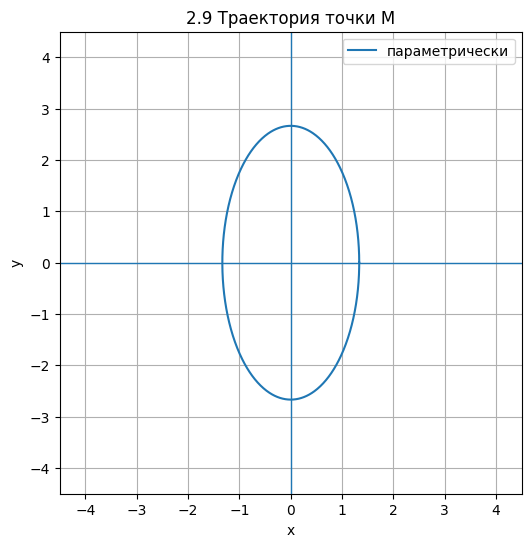

In [5]:
b = 4.0
lam = 2.0  

# A=(b cos t,0), B=(0,b sin t)
def sliding_point_xy(t, b=b, lam=lam):
    A = np.vstack([b*np.cos(t), np.zeros_like(t)])
    B = np.vstack([np.zeros_like(t), b*np.sin(t)])
    M = (A + lam * B) / (1 + lam)
    return M

alpha = b / (1 + lam)
beta = b * lam / (1 + lam)

def ellipse_F(X, Y):
    return X**2 / alpha**2 + Y**2 / beta**2 - 1

fig, ax = setup_2d((-4.5, 4.5), (-4.5, 4.5), title='2.9 Траектория точки M')
plot_parametric_2d(ax, sliding_point_xy, (0, 2*np.pi), n=800, label='параметрически')
plt.show()

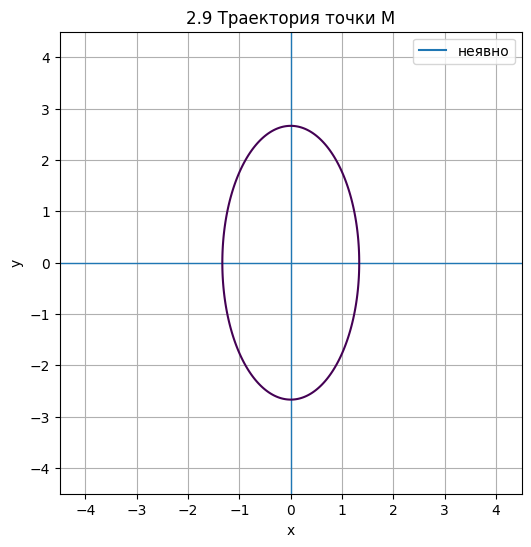

In [6]:
fig, ax = setup_2d((-4.5, 4.5), (-4.5, 4.5), title='2.9 Траектория точки M')
plot_implicit_2d(ax, ellipse_F, (-4.5, 4.5), (-4.5, 4.5), n=500, label='неявно')
plt.show()

## Общие функции для 3D

In [7]:
def set_axes_equal_3d(ax):
    """Делает масштабы по осям 3D одинаковыми."""
    x_limits = ax.get_xlim3d()
    y_limits = ax.get_ylim3d()
    z_limits = ax.get_zlim3d()
    x_range = abs(x_limits[1] - x_limits[0])
    y_range = abs(y_limits[1] - y_limits[0])
    z_range = abs(z_limits[1] - z_limits[0])
    radius = 0.5 * max([x_range, y_range, z_range])
    x_middle = np.mean(x_limits)
    y_middle = np.mean(y_limits)
    z_middle = np.mean(z_limits)
    ax.set_xlim3d([x_middle - radius, x_middle + radius])
    ax.set_ylim3d([y_middle - radius, y_middle + radius])
    ax.set_zlim3d([z_middle - radius, z_middle + radius])


def setup_3d(xlim=(-5, 5), ylim=(-5, 5), zlim=(-5, 5), title=None):
    """Создает 3D-систему координат."""
    fig = plt.figure(figsize=(8, 7))
    ax = fig.add_subplot(111, projection='3d')
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_zlim(*zlim)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('z')
    if title:
        ax.set_title(title)
    # оси координат
    ax.plot([xlim[0], xlim[1]], [0, 0], [0, 0], linewidth=1)
    ax.plot([0, 0], [ylim[0], ylim[1]], [0, 0], linewidth=1)
    ax.plot([0, 0], [0, 0], [zlim[0], zlim[1]], linewidth=1)
    return fig, ax


def plot_points_3d(ax, points, labels=None):
    labels = labels or [None] * len(points)
    for p, label in zip(points, labels):
        p = np.asarray(p, dtype=float)
        ax.scatter(p[0], p[1], p[2], s=45)
        if label:
            ax.text(p[0], p[1], p[2], '  ' + label)


def plot_parametric_3d(ax, r_func, t_range, n=800, label=None):
    """Рисует пространственную параметрическую кривую t -> (x(t), y(t), z(t))."""
    t = np.linspace(t_range[0], t_range[1], n)
    r = np.asarray(r_func(t), dtype=float)
    ax.plot(r[0], r[1], r[2], label=label)
    if label:
        ax.legend()
    return r


def plot_surface_3d(ax, r_func, u_range, v_range, nu=80, nv=80, alpha=0.45, label=None):
    """Рисует параметрическую поверхность r(u,v). r_func должен возвращать массивы X,Y,Z."""
    u = np.linspace(u_range[0], u_range[1], nu)
    v = np.linspace(v_range[0], v_range[1], nv)
    U, V = np.meshgrid(u, v)
    X, Y, Z = r_func(U, V)
    surf = ax.plot_surface(X, Y, Z, alpha=alpha, linewidth=0, antialiased=True)
    if label:
        surf.set_label(label)
    set_axes_equal_3d(ax)
    return X, Y, Z

## Задача 2.12 — кривая Вивиани

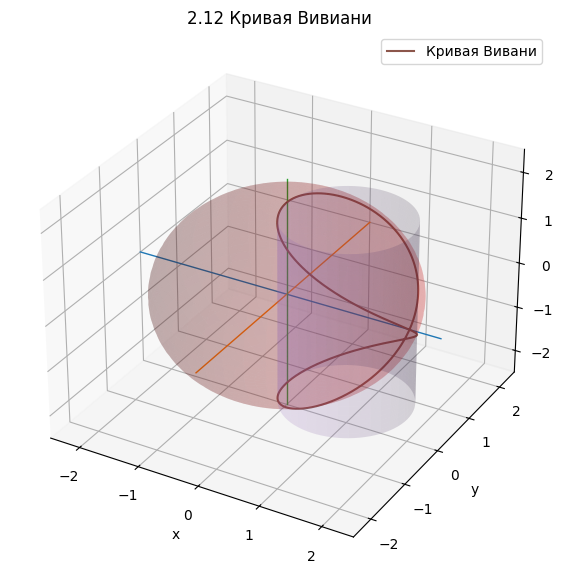

In [8]:
R = 2.0

# Сфера: x^2+y^2+z^2=R^2
# Цилиндр: (x-R/2)^2 + y^2 = (R/2)^2, то есть x^2+y^2=R x
# Параметризация кривой Вивиани:
def viviani(t, R=R):
    return np.vstack([
        R * np.cos(t)**2,
        R * np.cos(t) * np.sin(t),
        R * np.sin(t)
    ])


def sphere(u, v, R=R):
    return (R*np.cos(u)*np.cos(v), R*np.cos(u)*np.sin(v), R*np.sin(u))


def cylinder(u, v, R=R):
    # u — угол вокруг оси цилиндра, v — высота z
    return (R/2 + (R/2)*np.cos(u), (R/2)*np.sin(u), v)

fig, ax = setup_3d((-2.5, 2.5), (-2.5, 2.5), (-2.5, 2.5), title='2.12 Кривая Вивиани')
plot_surface_3d(ax, sphere, (-np.pi/2, np.pi/2), (0, 2*np.pi), alpha=0.18)
plot_surface_3d(ax, cylinder, (0, 2*np.pi), (-R, R), alpha=0.18)
plot_parametric_3d(ax, viviani, (0, 2*np.pi), n=1200, label='Кривая Вивани')
set_axes_equal_3d(ax)
plt.show()